In [ ]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#load wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

#create DataFrame for better understanding
df_wine = pd.DataFrame(X, columns = feature_names)
df_wine['target']= y

#split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state =42)

#Apply MinMax Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#train KNN Classifier (we'll use K=5)
knn_classifier = KNeighborsClassifier(n_neighbors =5)
knn_classifier.fit(X_train_scaled, y_train)

#Predict on test data
y_pred = knn_classifier.predict(X_test_scaled)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names = target_names)

accuracy, conf_matrix , class_report

(0.9444444444444444,
 array([[19,  0,  0],
        [ 1, 18,  2],
        [ 0,  0, 14]]),
 '              precision    recall  f1-score   support\n\n     class_0       0.95      1.00      0.97        19\n     class_1       1.00      0.86      0.92        21\n     class_2       0.88      1.00      0.93        14\n\n    accuracy                           0.94        54\n   macro avg       0.94      0.95      0.94        54\nweighted avg       0.95      0.94      0.94        54\n')

#### Confusion Matrix using seaborn

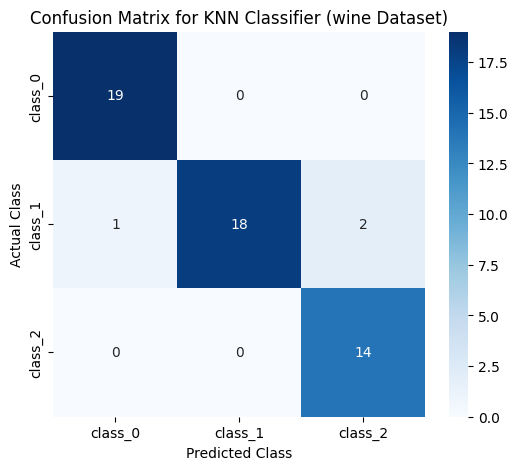

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot =True , fmt='d', cmap='Blues',
            xticklabels = target_names,
            yticklabels = target_names)

plt.title("Confusion Matrix for KNN Classifier (wine Dataset)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

The KNN model achieved strong performance on the wine dataset with minimal errors. Feature scaling played a key role in improving the model accuracy.